# 04 — PD WoE Binning

This notebook builds Weight of Evidence bins from the training data only.

Workflow:

1. load `X_train` and `y_train`;
2. create `bad_flag`;
3. separate categorical and numerical variables;
4. build bins separately;
5. merge results;
6. review IV and selected variables;
7. optionally define manual breaks;
8. export final bins.


In [1]:
from pathlib import Path
import sys

current_path = Path.cwd().resolve()

project_root = None

for path in [current_path, *current_path.parents]:
    if (path / "src").is_dir():
        project_root = path
        break

if project_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'src' depuis : {current_path}"
    )

sys.path.insert(0, str(project_root))

print("Current directory:", current_path)
print("Project root:", project_root)
print("src exists:", (project_root / "src").exists())
print("Python path added:", sys.path[0])

Current directory: C:\Users\Platini AGOUANET\Mes Dossiers lourds\risk-credit-scoring-new\notebooks
Project root: C:\Users\Platini AGOUANET\Mes Dossiers lourds\risk-credit-scoring-new
src exists: True
Python path added: C:\Users\Platini AGOUANET\Mes Dossiers lourds\risk-credit-scoring-new


In [2]:
from pathlib import Path
import pickle

import pandas as pd

from src.features.woe import (
    apply_woe, merge_bins, review_categorical_binning,
    review_all_categorical_binnings,
                    apply_woe
)
from src.features.binning import build_bins

c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load training data


In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SPLIT_DIR = PROJECT_ROOT / "data" / "processed" / "pd_split"

X_train = pd.read_parquet(SPLIT_DIR / "X_train.parquet")
y_train = pd.read_parquet(SPLIT_DIR / "y_train.parquet")
X_test = pd.read_parquet(SPLIT_DIR / "X_test.parquet")

train_data = X_train.merge(
    y_train[["source_row_index", "good_bad"]],
    on="source_row_index",
    how="inner",
    validate="one_to_one",
)

train_data = train_data.drop(columns="source_row_index")
train_data["bad_flag"] = 1 - train_data["good_bad"]
train_data = train_data.drop(columns="good_bad")

print(train_data.shape)
train_data.head()


(373028, 49)


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,home_ownership,annual_inc,verification_status,...,open_account_ratio,credit_inquiry_rate,delinquency_rate,emp_title_missing,loan_burden_interest,mths_since_last_record_is_missing,mths_since_last_major_derog_is_missing,mths_since_last_delinq_is_missing,open_account_inconsistency,bad_flag
0,15000,15000,15000.0,36,8.90,476.30,A,MORTGAGE,80000.0,Source Verified,...,0.593750,0.0,0.031250,0,1.668750,1,1,0,0,0
1,8000,8000,8000.0,60,18.25,204.24,D,OWN,44000.0,Verified,...,0.480000,0.054054,0.000000,0,3.318182,1,1,1,0,0
2,12150,12150,12100.0,60,18.92,314.65,D,OWN,27000.0,Source Verified,...,0.409091,0.0,0.045455,0,8.514000,1,1,0,0,0
3,10000,10000,10000.0,36,6.03,304.36,A,MORTGAGE,33000.0,Not Verified,...,0.294118,0.0,0.000000,0,1.827273,1,1,1,0,0
4,15825,15825,15825.0,36,12.12,526.53,B,MORTGAGE,59000.0,Verified,...,0.225806,0.0,0.000000,0,3.250831,1,1,1,0,1


## 2. Separate categorical and numerical variables


In [4]:
target = "bad_flag"
categorical_features = (
    train_data.drop(columns=target)
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

numeric_features = (
    train_data.drop(columns=target)
    .select_dtypes(include="number")
    .columns
    .tolist()
)

print(f"Categorical variables: {len(categorical_features)}")
print(f"Numerical variables: {len(numeric_features)}")


Categorical variables: 6
Numerical variables: 40


## 3. Build categorical bins


In [5]:
categorical_profile = (
    train_data[categorical_features]
    .nunique(dropna=False)
    .sort_values(ascending=False)
    .rename("unique_values")
    .to_frame()
)

categorical_profile["missing_percentage"] = (
    train_data[categorical_features]
    .isna()
    .mean()
    .mul(100)
)

display(categorical_profile)

,unique_values,missing_percentage
addr_state,50,0.0
purpose,14,0.0
grade,7,0.0
home_ownership,4,0.0
verification_status,3,0.0
initial_list_status,2,0.0


In [6]:
MANUAL_BREAKS = {}

categorical_bins, categorical_report = build_bins(
    data=train_data,
    variables=categorical_features,
    target=target,
    breaks_list=MANUAL_BREAKS
)
display(categorical_report)

#print(f"Categorical bins created: {len(categorical_bins)}")


[1/6] grade (7 values)
[INFO] creating woe binning ...


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWar

  SUCCESS — 1.20 seconds
[2/6] home_ownership (4 values)


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:332: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  init_bin = dtm.groupby('value', group_keys=False)['y'].agg([n0,n1])\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using Se

[INFO] creating woe binning ...


...

[INFO] creating woe binning ...


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWar

  SUCCESS — 1.19 seconds


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

,variable,status,unique_values,number_of_bins,information_value,manual_breaks_used,retry_used,duration_seconds,error_message
0,grade,success,7,5,0.288376,False,False,1.20,None
1,home_ownership,success,4,3,0.021326,False,False,1.15,None
2,verification_status,success,3,3,0.022522,False,False,1.11,None
3,purpose,success,14,4,0.031989,False,False,1.30,None
4,addr_state,success,50,4,0.010815,False,False,1.53,None
5,initial_list_status,success,2,2,0.025441,False,False,1.19,None


## binning Validation 


[1/6] Reviewing grade
Variable: grade
Original categories: 7
Automatic bins: 5
Original-category IV: 0.2921
Automatic-binning IV: 0.2884


,grade,total,distribution,bad_rate,woe,iv_component
0,G,2623,0.007032,0.278307,-1.145327,0.013991
1,F,10606,0.028432,0.241939,-0.955832,0.037028
2,E,28590,0.076643,0.195523,-0.683333,0.046380
3,D,61713,0.165438,0.154473,-0.397883,0.030535
4,C,100342,0.268993,0.114130,-0.048583,0.000647
5,B,109344,0.293125,0.078578,0.363997,0.033677
6,A,59810,0.160336,0.038639,1.116100,0.129882


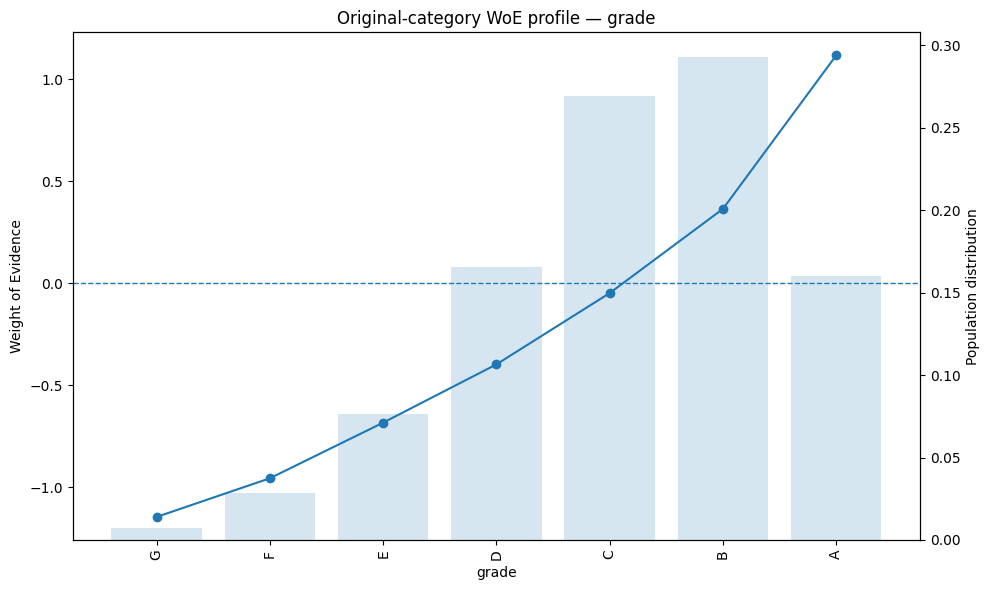

Automatic bins proposed by scorecardpy:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,grade,A,59810,0.160336,57499,2311,0.038639,-1.116232,0.129906,0.288376,A,False
1,grade,B,109344,0.293125,100752,8592,0.078578,-0.363975,0.033673,0.288376,B,False
2,grade,C,100342,0.268993,88890,11452,0.114130,0.048620,0.000648,0.288376,C,False
3,grade,D,61713,0.165438,52180,9533,0.154473,0.397915,0.030541,0.288376,D,False
4,grade,"E%,%F%,%G",41819,0.112107,32933,8886,0.212487,0.787857,0.093608,0.288376,"E%,%F%,%G",False


Original-category dispersion inside each automatic bin:


,bin,categories_expected,categories_matched,minimum_original_woe,maximum_original_woe,woe_range,weighted_bad_rate,total_observations,group_quality
0,A,1,1,1.116100,1.116100,0.000000,0.038639,59810,Homogeneous
1,B,1,1,0.363997,0.363997,0.000000,0.078578,109344,Homogeneous
2,C,1,1,-0.048583,-0.048583,0.000000,0.114130,100342,Homogeneous
3,D,1,1,-0.397883,-0.397883,0.000000,0.154473,61713,Homogeneous
4,"E%,%F%,%G",3,3,-1.145327,-0.683333,0.461994,0.212487,41819,Too heterogeneous



[2/6] Reviewing home_ownership
Variable: home_ownership
Original categories: 4
Automatic bins: 3
Original-category IV: 0.0217
Automatic-binning IV: 0.0213


,home_ownership,total,distribution,bad_rate,woe,iv_component
0,OTHER,200,0.000536,0.195000,-0.689608,0.000333
1,RENT,150776,0.404195,0.125948,-0.160568,0.011093
2,OWN,33313,0.089304,0.109657,-0.003682,0.000001
3,MORTGAGE,188739,0.505965,0.095857,0.146290,0.010225


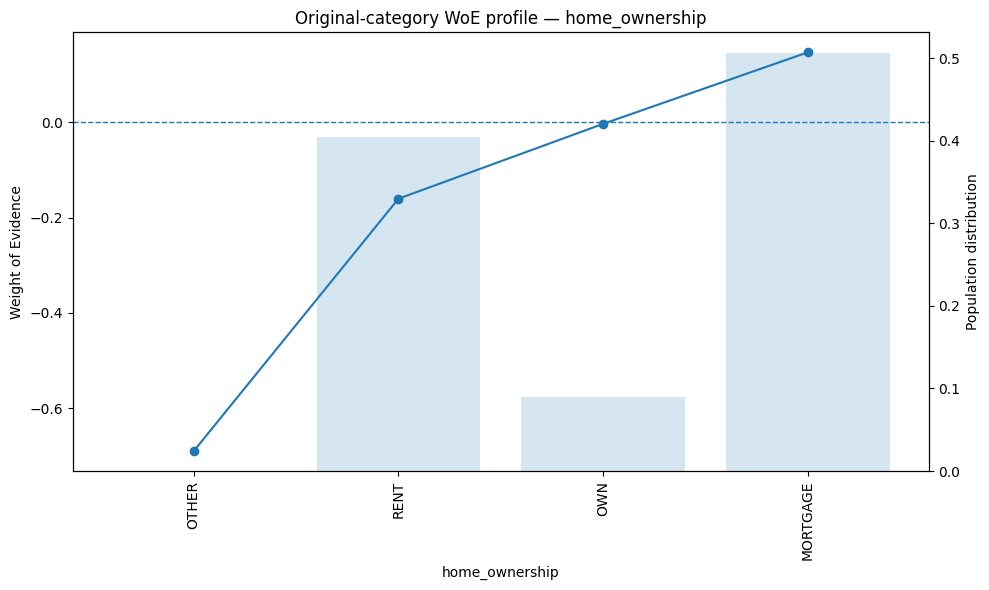

Automatic bins proposed by scorecardpy:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,home_ownership,MORTGAGE,188739,0.505965,170647,18092,0.095857,-0.146272,0.010223,0.021326,MORTGAGE,False
1,home_ownership,"OTHER%,%OWN",33513,0.089840,29821,3692,0.110166,0.008811,0.000007,0.021326,"OTHER%,%OWN",False
2,home_ownership,RENT,150776,0.404195,131786,18990,0.125948,0.160588,0.011096,0.021326,RENT,False


Original-category dispersion inside each automatic bin:


,bin,categories_expected,categories_matched,minimum_original_woe,maximum_original_woe,woe_range,weighted_bad_rate,total_observations,group_quality
0,MORTGAGE,1,1,0.146290,0.146290,0.000000,0.095857,188739,Homogeneous
1,"OTHER%,%OWN",2,2,-0.689608,-0.003682,0.685926,0.110166,33513,Too heterogeneous
2,RENT,1,1,-0.160568,-0.160568,0.000000,0.125948,150776,Homogeneous



[3/6] Reviewing verification_status
Variable: verification_status
Original categories: 3
Automatic bins: 3
Original-category IV: 0.0225
Automatic-binning IV: 0.0225


,verification_status,total,distribution,bad_rate,woe,iv_component
0,Verified,134571,0.360753,0.127955,-0.178683,0.012347
1,Source Verified,119969,0.321609,0.104277,0.052723,0.000876
2,Not Verified,118488,0.317638,0.093216,0.177119,0.009297


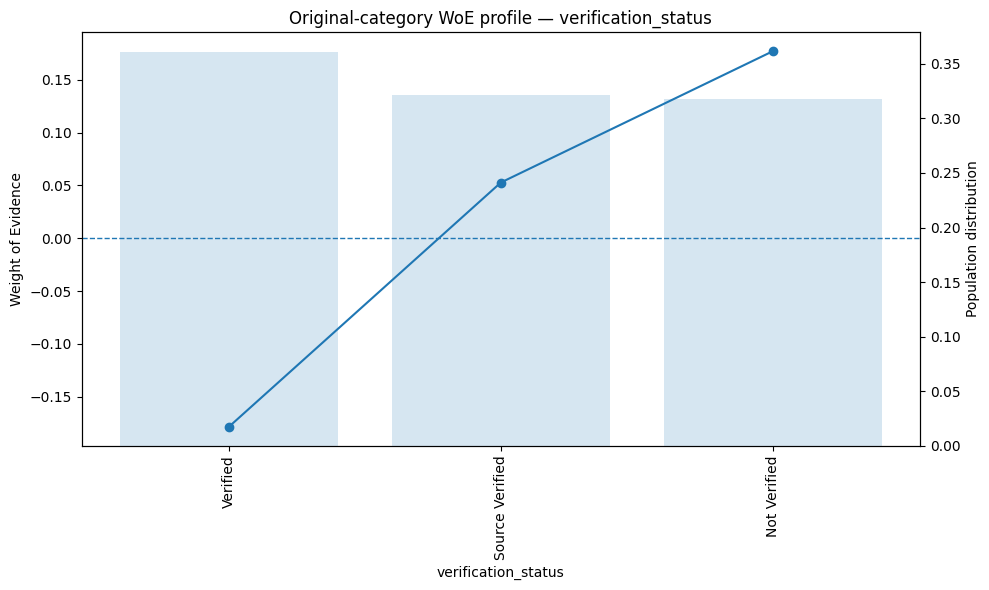

Automatic bins proposed by scorecardpy:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,verification_status,Not Verified,118488,0.317638,107443,11045,0.093216,-0.177128,0.009298,0.022522,Not Verified,False
1,verification_status,Source Verified,119969,0.321609,107459,12510,0.104277,-0.052726,0.000876,0.022522,Source Verified,False
2,verification_status,Verified,134571,0.360753,117352,17219,0.127955,0.178691,0.012348,0.022522,Verified,False


Original-category dispersion inside each automatic bin:


,bin,categories_expected,categories_matched,minimum_original_woe,maximum_original_woe,woe_range,weighted_bad_rate,total_observations,group_quality
0,Not Verified,1,1,0.177119,0.177119,0.0,0.093216,118488,Homogeneous
1,Source Verified,1,1,0.052723,0.052723,0.0,0.104277,119969,Homogeneous
2,Verified,1,1,-0.178683,-0.178683,0.0,0.127955,134571,Homogeneous



[4/6] Reviewing purpose
Variable: purpose
Original categories: 14
Automatic bins: 4
Original-category IV: 0.0367
Automatic-binning IV: 0.0320


,purpose,total,distribution,bad_rate,woe,iv_component
0,small_business,5605,0.015026,0.212667,-0.789088,0.012593
1,educational,351,0.000941,0.207977,-0.765572,0.000738
2,renewable_energy,295,0.000791,0.162712,-0.467858,0.000208
3,moving,2397,0.006426,0.151439,-0.375478,0.001048
4,house,1824,0.004890,0.138706,-0.273282,0.000406
5,other,19006,0.050951,0.138325,-0.268590,0.004079
6,medical,3750,0.010053,0.136533,-0.254140,0.000717
7,vacation,2003,0.005370,0.124314,-0.147224,0.000123
8,wedding,1900,0.005093,0.118947,-0.097180,0.000050
9,debt_consolidation,219196,0.587613,0.113296,-0.040213,0.000965


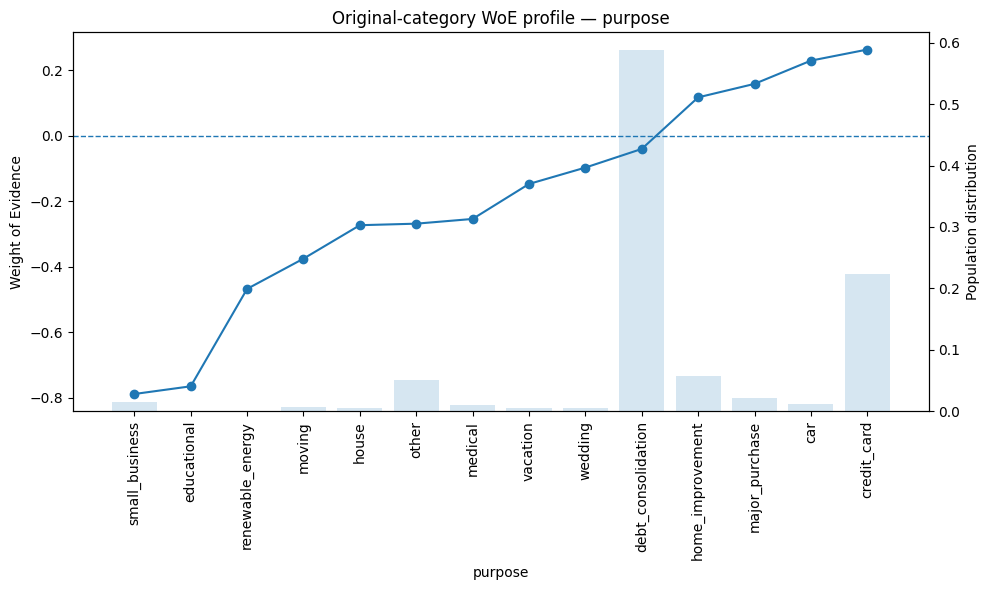

Automatic bins proposed by scorecardpy:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,purpose,"credit_card%,%car",87575,0.234768,80017,7558,0.086303,-0.261777,0.014520,0.031989,"credit_card%,%car",False
1,purpose,"major_purchase%,%home_improvement",29126,0.078080,26289,2837,0.097404,-0.128548,0.001227,0.031989,"major_purchase%,%home_improvement",False
2,purpose,"debt_consolidation%,%wedding%,%vacation",223099,0.598076,197790,25309,0.113443,0.041809,0.001063,0.031989,"debt_consolidation%,%wedding%,%vacation",False
3,purpose,"medical%,%other%,%house%,%moving%,%renewable_e...",33228,0.089076,28158,5070,0.152582,0.383364,0.015180,0.031989,"medical%,%other%,%house%,%moving%,%renewable_e...",False


Original-category dispersion inside each automatic bin:


,bin,categories_expected,categories_matched,minimum_original_woe,maximum_original_woe,woe_range,weighted_bad_rate,total_observations,group_quality
0,"credit_card%,%car",2,2,0.229605,0.263473,0.033867,0.086303,87575,Homogeneous
1,"major_purchase%,%home_improvement",2,2,0.117369,0.158616,0.041246,0.097404,29126,Homogeneous
2,"debt_consolidation%,%wedding%,%vacation",3,3,-0.147224,-0.040213,0.107011,0.113443,223099,Homogeneous
3,"medical%,%other%,%house%,%moving%,%renewable_e...",7,7,-0.789088,-0.254140,0.534949,0.152582,33228,Too heterogeneous



[5/6] Reviewing addr_state
Variable: addr_state
Original categories: 50
Automatic bins: 4
Original-category IV: 0.0123
Automatic-binning IV: 0.0108


,addr_state,total,distribution,bad_rate,woe,iv_component
0,NE,8,0.000021,0.500000,-2.097317,2.029238e-04
1,IA,7,0.000019,0.142857,-0.630980,1.085522e-05
2,ID,9,0.000024,0.111111,-0.362716,4.056872e-06
3,NV,5238,0.014042,0.136502,-0.253258,9.936907e-04
4,FL,25259,0.067713,0.126727,-0.167239,2.021012e-03
5,ME,3,0.000008,0.000000,-0.151407,2.607060e-07
6,HI,2012,0.005394,0.123260,-0.137138,1.070413e-04
7,AL,4698,0.012594,0.122393,-0.128099,2.172542e-04
8,MD,8811,0.023620,0.117126,-0.077808,1.474032e-04
9,OK,3301,0.008849,0.116631,-0.073719,4.950223e-05


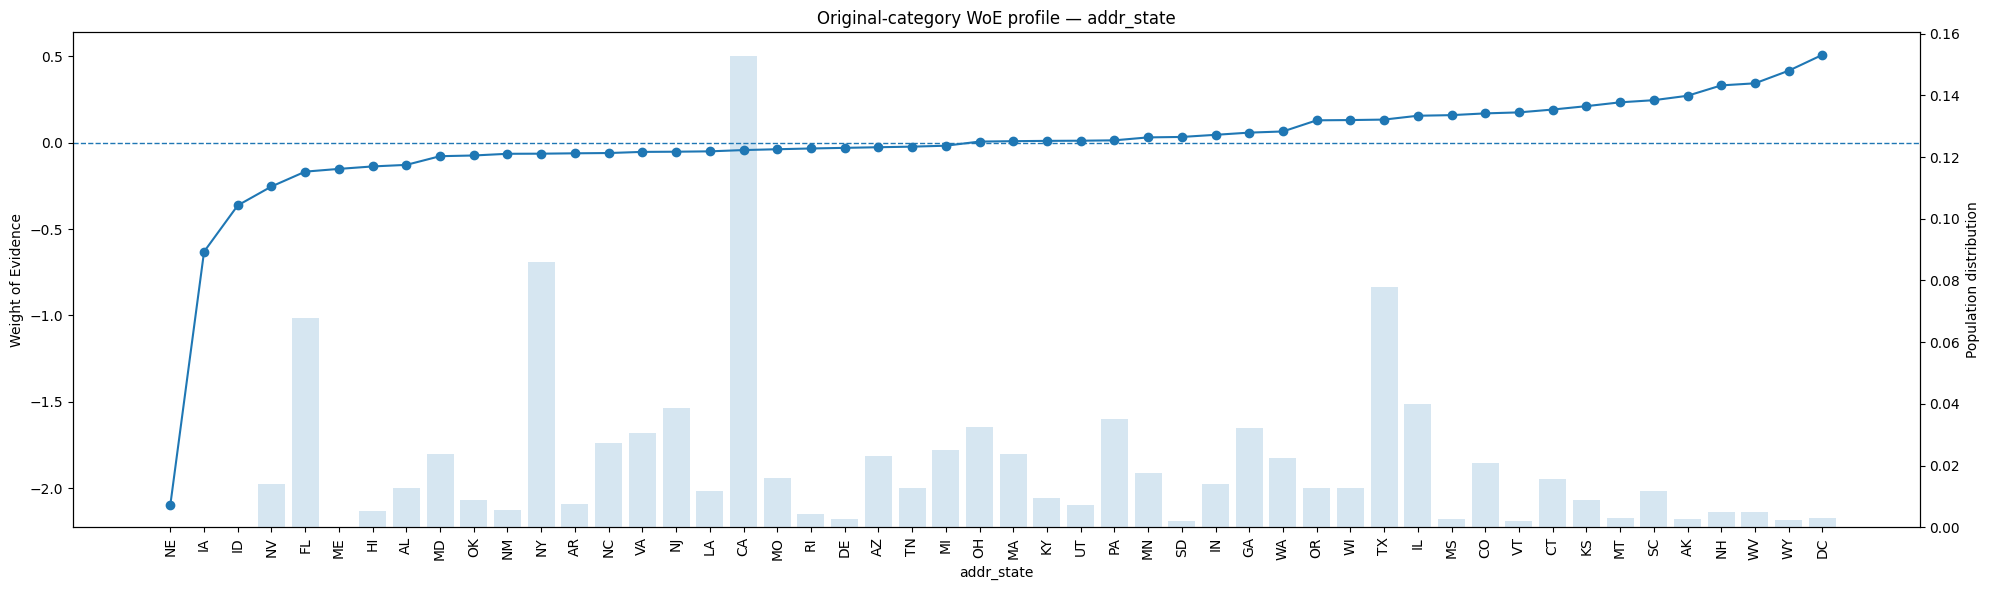

Automatic bins proposed by scorecardpy:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,addr_state,"ME%,%DC%,%WY%,%WV%,%NH%,%AK%,%SC%,%MT%,%KS%,%CT",21488,0.057604,19636,1852,0.086188,-0.263243,0.003601,0.010815,"ME%,%DC%,%WY%,%WV%,%NH%,%AK%,%SC%,%MT%,%KS%,%CT",False
1,addr_state,"VT%,%CO%,%MS%,%IL%,%TX%,%WI%,%OR%,%WA%,%GA",83457,0.223729,75290,8167,0.097859,-0.123391,0.003246,0.010815,"VT%,%CO%,%MS%,%IL%,%TX%,%WI%,%OR%,%WA%,%GA",False
2,addr_state,"IN%,%SD%,%MN%,%PA%,%UT%,%KY%,%MA%,%OH%,%MI%,%I...",230861,0.618884,204850,26011,0.112670,0.034097,0.000729,0.010815,"IN%,%SD%,%MN%,%PA%,%UT%,%KY%,%MA%,%OH%,%MI%,%I...",False
3,addr_state,"AL%,%HI%,%FL%,%NV%,%IA%,%NE",37222,0.099783,32478,4744,0.127452,0.174173,0.003239,0.010815,"AL%,%HI%,%FL%,%NV%,%IA%,%NE",False


Original-category dispersion inside each automatic bin:


,bin,categories_expected,categories_matched,minimum_original_woe,maximum_original_woe,woe_range,weighted_bad_rate,total_observations,group_quality
0,"ME%,%DC%,%WY%,%WV%,%NH%,%AK%,%SC%,%MT%,%KS%,%CT",10,10,-0.151407,0.509324,0.660732,0.086188,21488,Too heterogeneous
1,"VT%,%CO%,%MS%,%IL%,%TX%,%WI%,%OR%,%WA%,%GA",9,9,0.058723,0.175953,0.117230,0.097859,83457,Homogeneous
2,"IN%,%SD%,%MN%,%PA%,%UT%,%KY%,%MA%,%OH%,%MI%,%I...",25,25,-0.362716,0.046026,0.408743,0.112670,230861,Too heterogeneous
3,"AL%,%HI%,%FL%,%NV%,%IA%,%NE",6,6,-2.097317,-0.128099,1.969218,0.127452,37222,Too heterogeneous



[6/6] Reviewing initial_list_status
Variable: initial_list_status
Original categories: 2
Automatic bins: 2
Original-category IV: 0.0254
Automatic-binning IV: 0.0254


,initial_list_status,total,distribution,bad_rate,woe,iv_component
0,f,242325,0.649616,0.120450,-0.109671,0.008155
1,w,130703,0.350384,0.088644,0.232436,0.017283


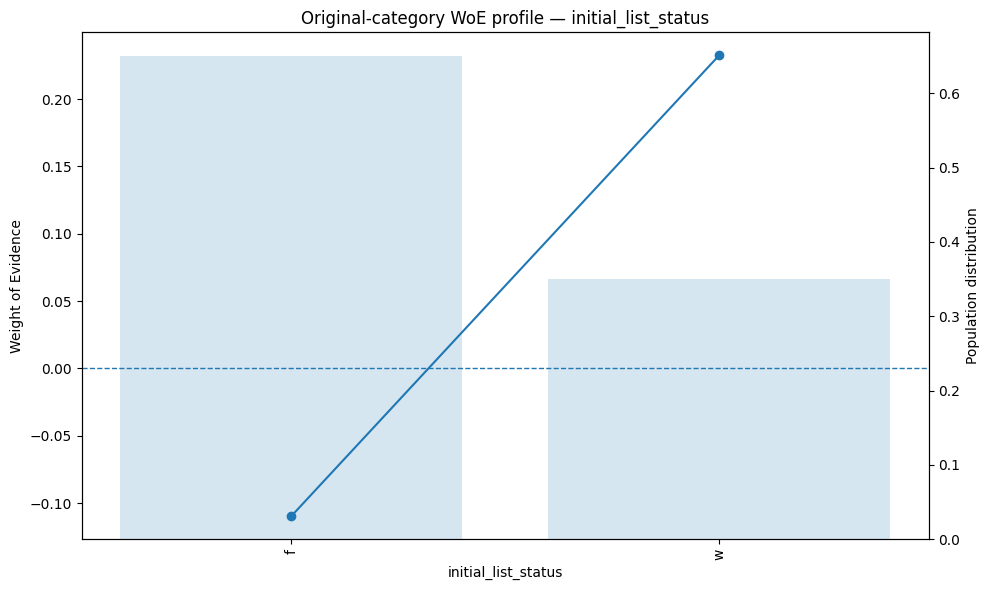

Automatic bins proposed by scorecardpy:


,variable,bin,count,count_distr,good,bad,badprob,woe,bin_iv,total_iv,breaks,is_special_values
0,initial_list_status,w,130703,0.350384,119117,11586,0.088644,-0.232454,0.017285,0.025441,w,False
1,initial_list_status,f,242325,0.649616,213137,29188,0.120450,0.109678,0.008156,0.025441,f,False


Original-category dispersion inside each automatic bin:


,bin,categories_expected,categories_matched,minimum_original_woe,maximum_original_woe,woe_range,weighted_bad_rate,total_observations,group_quality
0,w,1,1,0.232436,0.232436,0.0,0.088644,130703,Homogeneous
1,f,1,1,-0.109671,-0.109671,0.0,0.120450,242325,Homogeneous


In [7]:
categorical_profiles, categorical_comparisons, categorical_review_report = (
    review_all_categorical_binnings(
        data=train_data,
        variables=categorical_features,
        target=target,
        bins=categorical_bins,
        binning_report=categorical_report,
        show_profile_tables=True,
        show_plots=True,
    )
)

In [8]:
display(categorical_review_report)

,variable,review_status,original_categories,automatic_bins,original_iv,automatic_iv,heterogeneous_groups,groups_to_review,message
0,grade,review,7,5,0.292140,0.288376,1,0,
1,home_ownership,review,4,3,0.021652,0.021326,1,0,
2,verification_status,acceptable,3,3,0.022520,0.022522,0,0,
3,purpose,review,14,4,0.036710,0.031989,1,0,
4,addr_state,review,50,4,0.012344,0.010815,3,0,
5,initial_list_status,acceptable,2,2,0.025437,0.025441,0,0,


##  Optional manual adjustments

Manual breaks is added only after reviewing the automatic bins.


In [ ]:
MANUAL_BREAKS = {
    "addr_state": [
        "NV%,%IA%,%NE%,%ID", "FL", "ME%,%HI%,%OK%,%MD%,%AL%,%NM", "NY", "AR%,%NC%,%VA%,%NJ%,%LA", "CA",
        "MO%,%RI%,%DE%,%AZ%,%TN%,%MI%,%OH%,%MA%,%KY%,%UT%,%PA%,%MN%,%SD%,%IN%,%GA%,%WA%,%OR%,%WI",
        "TX%,%IL",
        "MS%,%CO%,%VT%,%CT%,%KS%,%MT%,%SC%,%AK%,%NH%,%WV%,%WY%,%DC"
    ],

    "grade": [
        "A", "B", "C", "D", "E", "F", "G"
    ],
    
    "home_ownership": [
        "MORTGAGE", "RENT", "OWN", "OTHER"
    ],
    
    "purpose": [
        "debt_consolidation",
        "small_business%,%educational",
        "credit_card",
        "home_improvement%,%major_purchase%,%car",
        "renewable_energy%,%moving",
        "house%,%other%,%medical",
        "vacation%,%wedding",
        
    ]
}


In [10]:
#Rebuilding bins with manual adjustments for categorical variables:

categorical_bins, categorical_report = build_bins(
    data=train_data,
    variables=categorical_features,
    target=target,
    breaks_list=MANUAL_BREAKS,
)

display(categorical_report)

[1/6] grade (7 values) — manual breaks
[INFO] creating woe binning ...


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWar

  SUCCESS — 1.21 seconds
[2/6] home_ownership (4 values) — manual breaks
[INFO] creating woe binning ...


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWar

  SUCCESS — 1.22 seconds
[3/6] verification_status (3 values)
[INFO] creating woe binning ...


...

  SUCCESS — 1.33 seconds
[6/6] initial_list_status (2 values)
[INFO] creating woe binning ...


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWar

  SUCCESS — 1.11 seconds


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a f

,variable,status,unique_values,number_of_bins,information_value,manual_breaks_used,retry_used,duration_seconds,error_message
0,grade,success,7,7,0.292145,True,False,1.21,None
1,home_ownership,success,4,4,0.021641,True,False,1.22,None
2,verification_status,success,3,3,0.022522,False,False,1.09,None
3,purpose,success,14,7,0.036531,True,False,1.29,None
4,addr_state,success,50,9,0.011084,True,False,1.33,None
5,initial_list_status,success,2,2,0.025441,False,False,1.11,None


In [11]:
display(categorical_report)

,variable,status,unique_values,number_of_bins,information_value,manual_breaks_used,retry_used,duration_seconds,error_message
0,grade,success,7,7,0.292145,True,False,1.21,None
1,home_ownership,success,4,4,0.021641,True,False,1.22,None
2,verification_status,success,3,3,0.022522,False,False,1.09,None
3,purpose,success,14,7,0.036531,True,False,1.29,None
4,addr_state,success,50,9,0.011084,True,False,1.33,None
5,initial_list_status,success,2,2,0.025441,False,False,1.11,None


## 4. Build numerical bins


In [12]:
import numpy as np
numeric_binning_data = train_data.copy()

for variable in numeric_features:
    numeric_binning_data[variable] = (
        pd.to_numeric(
            numeric_binning_data[variable],
            errors="coerce",
        )
        .astype("float64")
        .replace([np.inf, -np.inf], np.nan)
    )

In [13]:
'''credit_inquiry_bins, credit_inquiry_report = build_bins(
    data=numeric_binning_data,
    variables=["credit_inquiry_rate"],
    target=target,
)

display(credit_inquiry_report)'''

'credit_inquiry_bins, credit_inquiry_report = build_bins(\n    data=numeric_binning_data,\n    variables=["credit_inquiry_rate"],\n    target=target,\n)\n\ndisplay(credit_inquiry_report)'

In [14]:
numeric_bins, numeric_report = build_bins(
    data=train_data,
    variables=numeric_features,
    target=target,
)
display(numeric_report)

#print(f"Numerical bins created: {len(numeric_bins)}")


[1/40] loan_amnt (1349 values)
[INFO] creating woe binning ...


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:131: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 1]' has dtype incompatible with int8, please explicitly cast to a compatible dtype first.
  dat.loc[:,y] = dat[y].apply(lambda x: x if pd.isnull(x) else int(x)) #dat[y].astype(int)
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWar

  SUCCESS — 2.04 seconds
[2/40] funded_amnt (1351 values)


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:425: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: iv_01(x['good'], x['bad'])).reset_index(name='total_iv')
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
c:\Users\Platini AGOUANET\AppData\Local\Pro

[INFO] creating woe binning ...


...

c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:413: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['variable', 'bstbin', 'value'], group_keys=False)\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGrou

[INFO] creating woe binning ...


c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
c:\Users\Platini AGOUANET\AppData\Local\Programs\Python\Python313\Lib\site-packages\scorecardpy\woebin.py:320: Futu

  SUCCESS — 1.27 seconds


,variable,status,unique_values,number_of_bins,information_value,manual_breaks_used,retry_used,duration_seconds,error_message
0,loan_amnt,success,1349,8,4.476565e-03,False,False,2.04,None
1,funded_amnt,success,1351,8,4.540670e-03,False,False,2.00,None
2,funded_amnt_inv,success,8178,8,4.702171e-03,False,False,2.08,None
3,term,success,2,2,4.079432e-02,False,False,1.42,None
4,int_rate,success,503,5,3.194342e-01,False,False,2.11,None
5,installment,success,51397,6,6.373214e-03,False,False,2.34,None
6,annual_inc,success,26982,5,4.897599e-02,False,False,2.00,None
7,dti,success,3997,4,2.540486e-02,False,False,1.93,None
8,delinq_2yrs,success,25,4,8.862880e-05,False,False,1.50,None
9,inq_last_6mths,success,29,5,4.885104e-02,False,False,1.51,None


## 5. Merge all bins


In [15]:
final_bins = merge_bins(
    categorical_bins,
    numeric_bins,
)

print(f"Total variables binned: {len(final_bins)}")


Total variables binned: 46


## 6. Build the IV report


In [16]:
iv_report = pd.DataFrame([
    {
        "variable": variable,
        "information_value": (
            float(table["total_iv"].iloc[0])
            if "total_iv" in table.columns
            else float(table["bin_iv"].sum())
        ),
        "number_of_bins": len(table),
    }
    for variable, table in final_bins.items()
]).sort_values("information_value", ascending=False)

iv_report.head(30)


,variable,information_value,number_of_bins
10,int_rate,0.319434,5
0,grade,0.292145,7
41,loan_burden_interest,0.188943,6
36,installment_to_income_ratio,0.067800,5
27,tot_cur_bal,0.063446,5
28,total_rev_hi_lim,0.062529,6
35,loan_to_income_ratio,0.059787,5
38,credit_inquiry_rate,0.059205,5
12,annual_inc,0.048976,5
15,inq_last_6mths,0.048851,5


## 9. Export final bins and IV report


In [17]:
final_bins = merge_bins(
    categorical_bins,
    numeric_bins
)
#print(final_bins)

In [18]:
MODEL_DIR = PROJECT_ROOT / "models" / "pd_binning"
REPORT_DIR = PROJECT_ROOT / "reports" / "pd_binning"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

with open(MODEL_DIR / "final_woe_bins.pkl", "wb") as file:
    pickle.dump(final_bins, file)

iv_report.to_csv(
    REPORT_DIR / "iv_report.csv",
    index=False,
)

print("Final bins and IV report exported.")


Final bins and IV report exported.


## 10. Transform X_train and X_text with the same bins and save 

In [19]:
X_train_woe = apply_woe(
    X_train,
    final_bins,
)

X_test_woe = apply_woe(
    X_test,
    final_bins,
)

X_train_woe.to_parquet( REPORT_DIR / "X_train_woe.parquet", index=False)
X_test_woe.to_parquet( REPORT_DIR / "X_test_woe.parquet", index=False)


[INFO] converting into woe values ...
Woe transformating on 373028 rows and 46 columns in 00:00:30
[INFO] converting into woe values ...


In [20]:
X_train_woe.to_csv( REPORT_DIR / "X_train_woe.csv", index=False)

## Next step

The next notebook will:

1. select the final variables;
2. apply the saved bins to train and test;
3. train the logistic regression model;
4. evaluate probability of default and calibration.
